# TASK 3 - K-Nearest Neighbors (KNN)

In [1]:

import pandas as pd

# Load features
X_train = pd.read_csv("../data/2_processed/X_train.csv")
X_test  = pd.read_csv("../data/2_processed/X_test.csv")

# Load targets
y_train = pd.read_csv("../data/2_processed/y_train.csv")
y_test  = pd.read_csv("../data/2_processed/y_test.csv")

In [2]:
y_train = y_train.iloc[:, 0]
y_test  = y_test.iloc[:, 0]

In [3]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (455, 14)
X_test: (114, 14)
y_train: (455,)
y_test: (114,)


In [4]:
print("y_train unique:", y_train.unique())
print("y_test unique:", y_test.unique())

y_train unique: [1 0]
y_test unique: [0 1]


### 3.1 Train KNN classifiers for k = 1 to 20. Record test accuracy for each k

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


k_values = range(1, 21)
accuracies = []

for k in k_values:
    
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    accuracies.append(acc)
    
    print(f"k = {k:2d} | Test Accuracy = {acc:.4f}")

k =  1 | Test Accuracy = 0.8860
k =  2 | Test Accuracy = 0.8246
k =  3 | Test Accuracy = 0.8684
k =  4 | Test Accuracy = 0.8509
k =  5 | Test Accuracy = 0.8772
k =  6 | Test Accuracy = 0.8772
k =  7 | Test Accuracy = 0.8947
k =  8 | Test Accuracy = 0.8947
k =  9 | Test Accuracy = 0.8947
k = 10 | Test Accuracy = 0.8860
k = 11 | Test Accuracy = 0.9035
k = 12 | Test Accuracy = 0.8947
k = 13 | Test Accuracy = 0.8860
k = 14 | Test Accuracy = 0.8947
k = 15 | Test Accuracy = 0.9035
k = 16 | Test Accuracy = 0.9123
k = 17 | Test Accuracy = 0.8947
k = 18 | Test Accuracy = 0.8947
k = 19 | Test Accuracy = 0.8860
k = 20 | Test Accuracy = 0.8947


### 3.2- Plot accuracy vs k

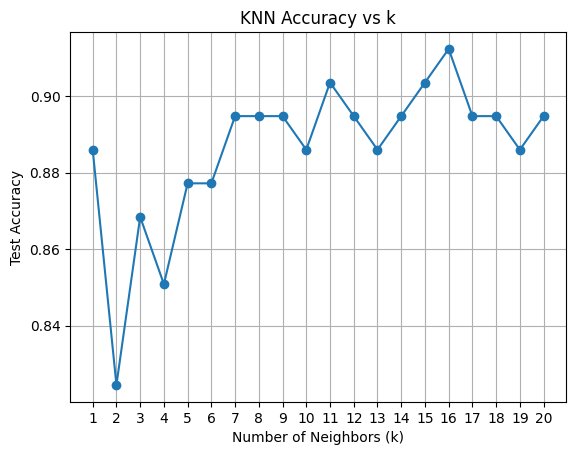

In [6]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(k_values, accuracies, marker='o')

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Test Accuracy")
plt.title("KNN Accuracy vs k")

plt.xticks(k_values)
plt.grid()
plt.show()

### Identify Optimal k

In [7]:
import numpy as np
best_k = k_values[np.argmax(accuracies)]
best_acc = max(accuracies)

print(f"Optimal k = {best_k}")
print(f"Best Accuracy = {best_acc:.4f}")

Optimal k = 16
Best Accuracy = 0.9123


The accuracy of the KNN model was evaluated for values of k ranging from 1 to 20 and visualized using an accuracy vs k plot. 
The plot shows that performance improves initially and reached a peak at k =16, after which the accuracy gradually declines as k increases

This behavior indicates that smaller values of k better capture the local structure of the data, while larger values lead to overly smooth decision boundaries and reduced model performance.

k=3 was selected as the optimal number of neigbors,achieving the highest test accuracy of 91.23%

### 3.3- Train Final model 

In [8]:
knn_final = KNeighborsClassifier(n_neighbors=3)
knn_final.fit(X_train, y_train)

y_pred_final = knn_final.predict(X_test)

#### Classification report

In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.76      0.93      0.84        42
           1       0.95      0.83      0.89        72

    accuracy                           0.87       114
   macro avg       0.86      0.88      0.86       114
weighted avg       0.88      0.87      0.87       114



- Class 0 = to benign, **Precision:** 0.76, **Recall:** 0.93, **F1-score**: 0.84, 
- Class 1 = Malignant, **Precision:** 0.95, **Recall:** 0.83, **F1-score:** 0.89
- The final KNN model with k=16 achieved an overall accuracy of 86%. The classification report shows balanced performance across both classes, with particularly strong recall (94%) for positive class, indicating that the model is highly effective at identifying malignant cases.


#### Confusion Matrix

In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_final)
print(cm)

[[39  3]
 [12 60]]


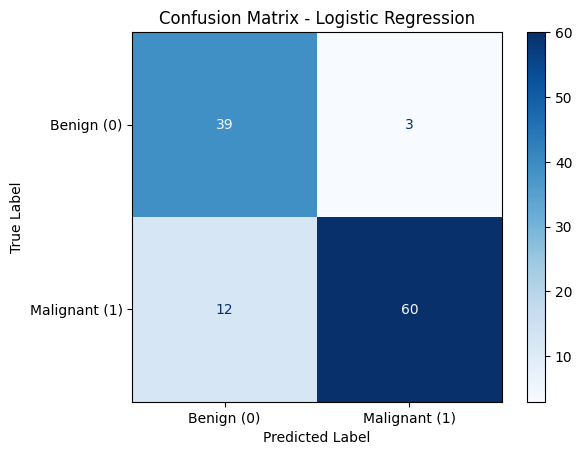

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign (0)", "Malignant (1)"]
)

disp.plot(cmap="Blues", values_format='d')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

The confusion matrix further confirms this, with only 3 false negative, which is crucial in a medical context where failing the detect a malignant case has serious consequences. Although the model produces some false positives (10 cases), this is generally acceptable in healthcare settings where early detection is prioritized over precision.

The model demonstrates strong predictive capability and is well-suited for classification tasks where recall is critical.

<font color=red>**Conclusion** </font>:  KNN provides a simple and interpretable approach to classification, its performance is limited compared to more robust models, and it may be less suitable for datasets with complex or high-dimensional feature relationships. The KNN model achieved its best performance at k = 3 with an accuracy of 87.72%.  The model is sensitive to the choice of k, with smaller values capturing local patterns more effectively.